In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import pickle
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import re
def extract_mouse_day(fname):
    match = re.search(r'M(\d+)_D(\d+)', fname)
    if match:
        mouse = int(match.group(1))
        day = int(match.group(2))
        return mouse, day
    else:
        return None, None

def get_trial_labels(mouse,day,fig_path='/Users/harryclark/Documents/figs/FIGURE1/'):
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
    mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x') 
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')

    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                    figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

    # we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
    # as defined by activity in the open field
    g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
    cluster_ids_by_group = []
    cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
    cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
    cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
    cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
    cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]
    
    tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

    last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

    # time binned variables for later
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
    speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
    dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(pos_in_time)):
        series = pd.Series(dt_in_time)
        filled_series = series.ffill().bfill()
        dt_in_time = np.array(filled_series)
        pos_in_time = dt_in_time%tl
        trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

    if np.any(np.isnan(speed_in_time)):
        series = pd.Series(speed_in_time)
        filled_series = series.ffill().bfill()
        speed_in_time = np.array(speed_in_time)

    # compute the spectrogram and labels from the most adunant grid module
    peak_indices = [28, 44, 60, 76]
    if len(g_m_cluster_ids)>0:
        cluster_ids = g_m_cluster_ids[0]
        got_from_grid = True
    else:
        cluster_ids = cluster_ids_by_group[1]
        got_from_grid = False
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    fvalid = results[5]
    S = spectrograms.mean(0)
    max_peaks = np.argmax(S, axis=0)
    #max_peaks = np.argmax(S[20:], axis=0) + 20
    labels = np.isin(max_peaks, peak_indices).astype(int)

    plt.figure(figsize=(4, 4))
    plt.imshow(S)
    plt.plot(max_peaks, color='red', linewidth=2, label='max_peaks')
    plt.tight_layout()
    plt.show()

    # compute trial labels for task anchoring to use in the xgboost model mask
    tc = tcs[cluster_ids[0]] # example grid cell
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
    return trial_labels, got_from_grid

Loaded 8 pickle files: ['M28_D23.pkl', 'M29_D25.pkl', 'M28_D25.pkl', 'M29_D23.pkl', 'M26_D15.pkl', 'M28_D17.pkl', 'M21_D16.pkl', 'M25_D25.pkl']

Processing session: M28_D23.pkl (mouse 28, day 23)
28 23
optimal travel lag is 7.257257257257258 cm based on kde of travel at max spatial information
optimal travel lag is 7.257257257257258 cm
there are 130 non_grid and non_spatial_cells
there are 7 grid_cells
there are 97 non grid spatial cells
there are 33 non spatial cells
there are 0 speed cells
there are 137 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
unique brain regions ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
there are 131 MEC cells
there are 10 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 141 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set

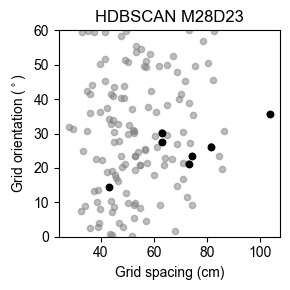

Identified 1 candidate modules


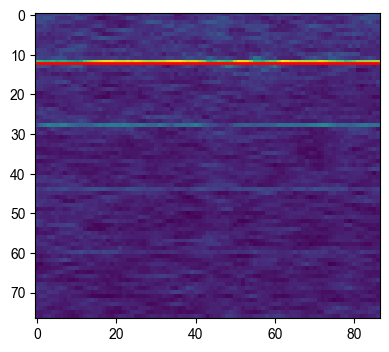

28 23
optimal travel lag is 7.257257257257258 cm based on kde of travel at max spatial information
optimal travel lag is 7.257257257257258 cm
there are 130 non_grid and non_spatial_cells
there are 7 grid_cells
there are 97 non grid spatial cells
there are 33 non spatial cells
there are 0 speed cells
there are 137 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Found 1 modules with HDBSCAN for mouse 28 day 23
for each module , the number of points is: [7]


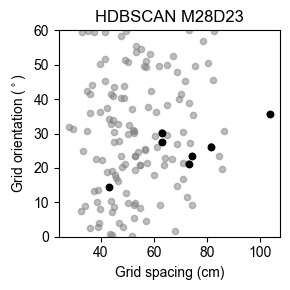

No module_1 cells found for mouse 28, day 23
Skipping session M28_D23.pkl due to missing dominant shank or no module_1 cells.

Processing session: M29_D25.pkl (mouse 29, day 25)
29 25
optimal travel lag is 7.157157157157158 cm based on kde of travel at max spatial information
optimal travel lag is 7.157157157157158 cm
there are 211 non_grid and non_spatial_cells
there are 10 grid_cells
there are 131 non grid spatial cells
there are 80 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5' 'PAR']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
there are 191 MEC cells
there are 60 PARA cells
there are 0 PRE cells
there are 20 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 271 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated

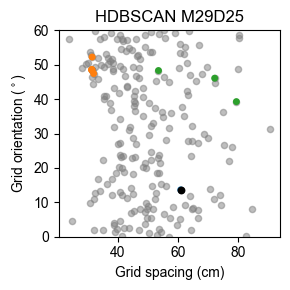

for module 0, there are 6 cells with average spacing 31.541636351465446
for module 1, there are 3 cells with average spacing 68.42440172931934
Identified 1 candidate modules


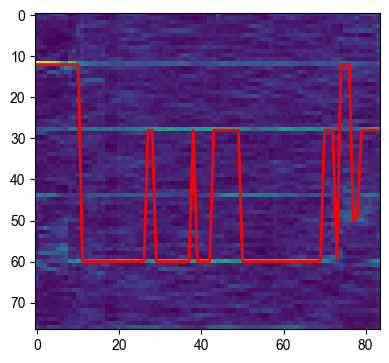

29 25
optimal travel lag is 7.157157157157158 cm based on kde of travel at max spatial information
optimal travel lag is 7.157157157157158 cm
there are 211 non_grid and non_spatial_cells
there are 10 grid_cells
there are 131 non grid spatial cells
there are 80 non spatial cells
there are 0 speed cells
there are 221 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a']
for the grid cells the unique locations are ['ENTm3' 'ENTm5' 'PAR']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 37.14538670493277
Found 3 modules with HDBSCAN for mouse 29 day 25
for each module , the number of points is: [1 6 3]


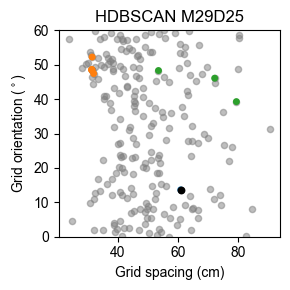

for module 0, there are 6 cells with average spacing 31.541636351465446
for module 1, there are 3 cells with average spacing 68.42440172931934
Module 1 cells for mouse 29, day 25 are mostly on shank 2 (counts: {2: np.int64(6)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(368), np.int64(370), np.int64(377), np.int64(385), np.int64(387)]
    Module 1: TI mean=-0.032, TA mean=-0.047, n_cells=5, cell_count_mean=4.0
    NGS Same Shank: TI mean=0.004, TA mean=0.099, n_cells=5, cell_count_mean=24.0
    NGS Other Shanks: TI mean=-0.111, TA mean=-0.025, n_cells=5, cell_count_mean=35.7

Processing session: M28_D25.pkl (mouse 28, day 25)
28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial

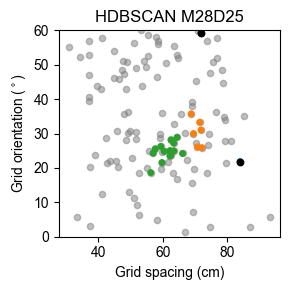

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Identified 1 candidate modules


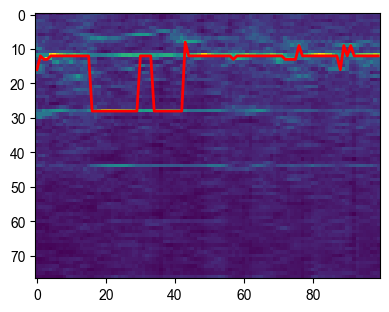

28 25
optimal travel lag is 9.75975975975976 cm based on kde of travel at max spatial information
optimal travel lag is 9.75975975975976 cm
there are 106 non_grid and non_spatial_cells
there are 23 grid_cells
there are 94 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 129 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a' 'VISpor5']
for the grid cells the unique locations are ['ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 10.95007559047365
Found 3 modules with HDBSCAN for mouse 28 day 25
for each module , the number of points is: [ 2  6 15]


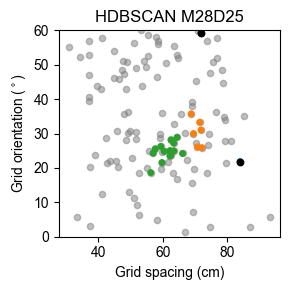

for module 0, there are 6 cells with average spacing 70.76972276610992
for module 1, there are 15 cells with average spacing 61.33629235763494
Module 1 cells for mouse 28, day 25 are mostly on shank 1 (counts: {1: np.int64(14), 2: np.int64(1)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(126), np.int64(139), np.int64(147), np.int64(149), np.int64(151), np.int64(153), np.int64(154), np.int64(155), np.int64(156), np.int64(158), np.int64(160), np.int64(162), np.int64(174), np.int64(188), np.int64(284)]
    Module 1: TI mean=0.060, TA mean=0.103, n_cells=15, cell_count_mean=14.0
    NGS Same Shank: TI mean=0.018, TA mean=0.077, n_cells=15, cell_count_mean=10.0
    NGS Other Shanks: TI mean=-0.045, TA mean=0.035, n_cells=15, cell_count_mean=28.0

Processing session: M29_D23.pkl (mouse 29, day 23)
29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spa

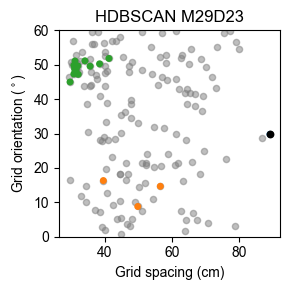

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
Identified 1 candidate modules


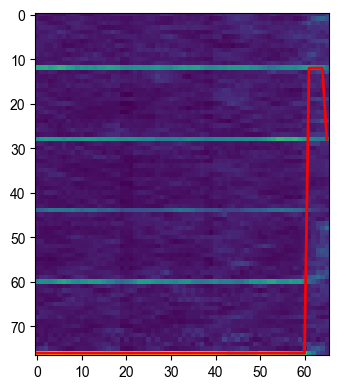

29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spatial_cells
there are 19 grid_cells
there are 114 non grid spatial cells
there are 27 non spatial cells
there are 0 speed cells
there are 160 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 39.09368458573167
Found 3 modules with HDBSCAN for mouse 29 day 23
for each module , the number of points is: [ 1  3 15]


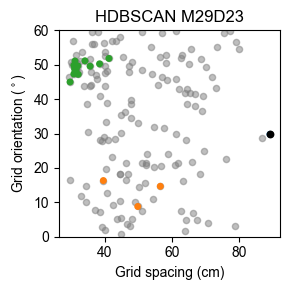

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
Module 1 cells for mouse 29, day 23 are mostly on shank 2 (counts: {2: np.int64(11), 3: np.int64(4)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(160), np.int64(184), np.int64(191), np.int64(194), np.int64(202), np.int64(213), np.int64(214), np.int64(216), np.int64(217), np.int64(219), np.int64(389), np.int64(411)]
    Module 1: TI mean=0.031, TA mean=0.056, n_cells=12, cell_count_mean=11.0
    NGS Same Shank: TI mean=0.039, TA mean=0.056, n_cells=12, cell_count_mean=14.0
    NGS Other Shanks: TI mean=-0.003, TA mean=0.010, n_cells=12, cell_count_mean=33.3

Processing session: M26_D15.pkl (mouse 26, day 15)
26 15
optimal travel lag is 10.660660660660668 cm based on kde of travel at max spatial information
optimal travel lag is 10.660660660660668 cm
there are 133 non_grid and non_spatial_cells
there are 8 grid_cells
there ar

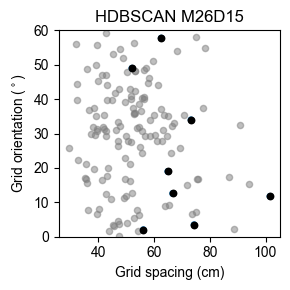

Identified 1 candidate modules


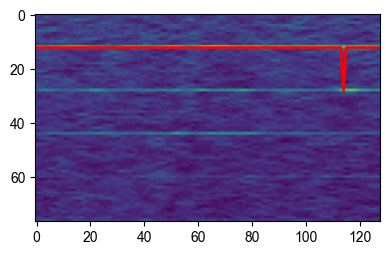

26 15
optimal travel lag is 10.660660660660668 cm based on kde of travel at max spatial information
optimal travel lag is 10.660660660660668 cm
there are 133 non_grid and non_spatial_cells
there are 8 grid_cells
there are 95 non grid spatial cells
there are 38 non spatial cells
there are 0 speed cells
there are 141 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm3' 'PAR' 'VISpl5']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Found 1 modules with HDBSCAN for mouse 26 day 15
for each module , the number of points is: [8]


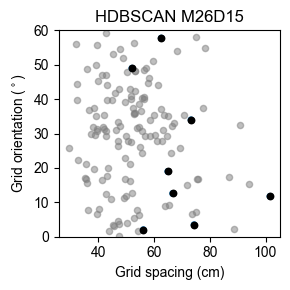

No module_1 cells found for mouse 26, day 15
Skipping session M26_D15.pkl due to missing dominant shank or no module_1 cells.

Processing session: M28_D17.pkl (mouse 28, day 17)
28 17
optimal travel lag is 11.161161161161168 cm based on kde of travel at max spatial information
optimal travel lag is 11.161161161161168 cm
there are 91 non_grid and non_spatial_cells
there are 7 grid_cells
there are 71 non grid spatial cells
there are 20 non spatial cells
there are 0 speed cells
there are 98 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'VISpl5' 'VISpl6a']
unique brain regions ['ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a']
there are 71 MEC cells
there are 7 PARA cells
there are 0 PRE cells
there are 23 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 101 all cells
params min_cluster_size and cluster_selection_epsilon are

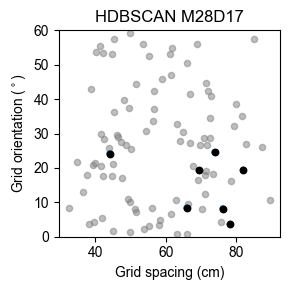

Identified 1 candidate modules


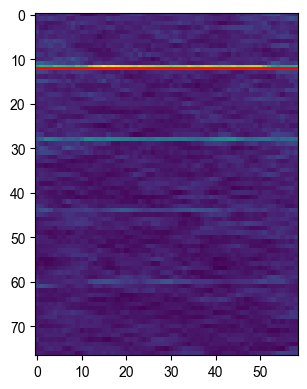

28 17
optimal travel lag is 11.161161161161168 cm based on kde of travel at max spatial information
optimal travel lag is 11.161161161161168 cm
there are 91 non_grid and non_spatial_cells
there are 7 grid_cells
there are 71 non grid spatial cells
there are 20 non spatial cells
there are 0 speed cells
there are 98 cells
for the non-grid spatial cells the unique locations are ['ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpl6a']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'VISpl5' 'VISpl6a']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Only one cluster found, attempting to create a new cluster around centroid
Found 1 modules with HDBSCAN for mouse 28 day 17
for each module , the number of points is: [7]


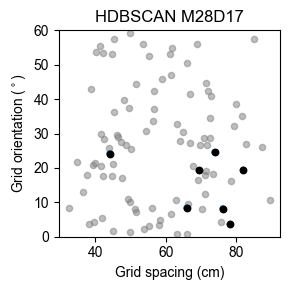

No module_1 cells found for mouse 28, day 17
Skipping session M28_D17.pkl due to missing dominant shank or no module_1 cells.

Processing session: M21_D16.pkl (mouse 21, day 16)
21 16
optimal travel lag is 10.360360360360367 cm based on kde of travel at max spatial information
optimal travel lag is 10.360360360360367 cm
there are 216 non_grid and non_spatial_cells
there are 15 grid_cells
there are 165 non grid spatial cells
there are 51 non spatial cells
there are 0 speed cells
there are 231 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
there are 242 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 242 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, thes

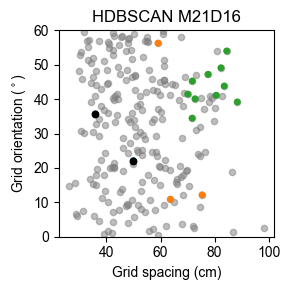

for module 0, there are 3 cells with average spacing 66.0058949975011
for module 1, there are 10 cells with average spacing 78.27797696247492
Identified 1 candidate modules


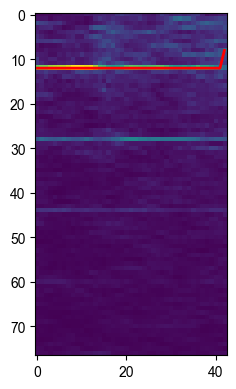

21 16
optimal travel lag is 10.360360360360367 cm based on kde of travel at max spatial information
optimal travel lag is 10.360360360360367 cm
there are 216 non_grid and non_spatial_cells
there are 15 grid_cells
there are 165 non grid spatial cells
there are 51 non spatial cells
there are 0 speed cells
there are 231 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'ENTm6']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 21.071326809552424
Found 3 modules with HDBSCAN for mouse 21 day 16
for each module , the number of points is: [ 2  3 10]


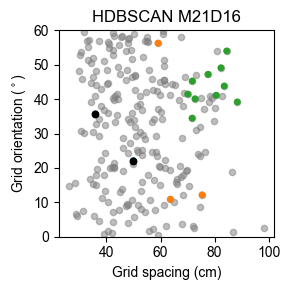

for module 0, there are 3 cells with average spacing 66.0058949975011
for module 1, there are 10 cells with average spacing 78.27797696247492
Module 1 cells for mouse 21, day 16 are mostly on shank 3 (counts: {3: np.int64(2), 2: np.int64(1)})
  Group: Module 1
    Module 1 test_cell_ids in group: []
    No module_1 test_cell_ids in this group.
Session M21_D16.pkl excluded: missing both task-anchored and task-independent firing for module_1 cells.

Processing session: M25_D25.pkl (mouse 25, day 25)
25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/

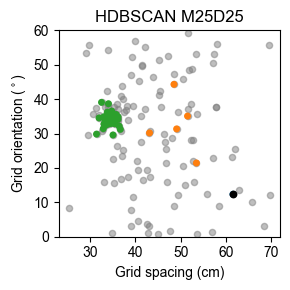

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules


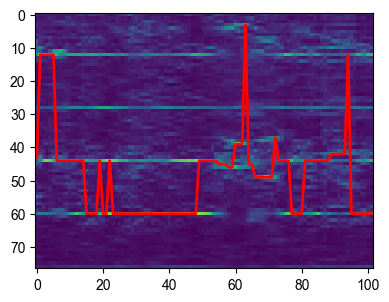

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 1  5 30]


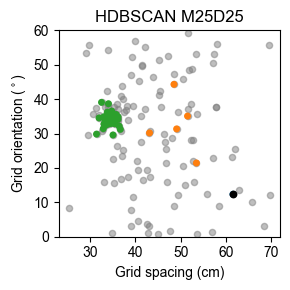

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Module 1 cells for mouse 25, day 25 are mostly on shank 2 (counts: {2: np.int64(14), 1: np.int64(13), 0: np.int64(3)})
  Group: Module 1
    Module 1 test_cell_ids in group: [np.int64(3), np.int64(14), np.int64(15), np.int64(69), np.int64(71), np.int64(76), np.int64(83), np.int64(87), np.int64(91), np.int64(96), np.int64(101), np.int64(104), np.int64(105), np.int64(109), np.int64(111), np.int64(120), np.int64(207), np.int64(214), np.int64(215), np.int64(219), np.int64(227), np.int64(230), np.int64(231), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(250), np.int64(264)]
    Module 1: TI mean=0.144, TA mean=0.146, n_cells=29, cell_count_mean=28.0
    NGS Same Shank: TI mean=0.039, TA mean=0.061, n_cells=29, cell_count_mean=39.0
    NGS Other Shanks: TI mean=0.043, TA mean=0.060, n_cells=29, cell_count_mean=11.7


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')

results_path = '/Users/harryclark/Downloads/COHORT12/multishank_xgboost/'
pkl_files = [f for f in os.listdir(results_path) if f.endswith('.pkl')]
loaded_pickles = {}
for fname in pkl_files:
    with open(os.path.join(results_path, fname), 'rb') as f:
        loaded_pickles[fname] = pickle.load(f)
print(f"Loaded {len(loaded_pickles)} pickle files:", list(loaded_pickles.keys()))



def get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day):
    if len(g_m_cluster_ids) == 0:
        print(f"No module_1 cells found for mouse {mouse}, day {day}")
        return None
    module_1_ids = g_m_cluster_ids[0]
    locs = locations[(locations['mouse'] == mouse) & (locations['day'] == day)]
    shank_counts = locs[locs['cluster_id'].isin(module_1_ids)]['shank_id'].value_counts()
    if len(shank_counts) == 0:
        print(f"No location info for module_1 cells for mouse {mouse}, day {day}")
        return None
    print(f"Module 1 cells for mouse {mouse}, day {day} are mostly on shank {shank_counts.idxmax()} (counts: {dict(shank_counts)})")
    return shank_counts.idxmax()

session_results = []
for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)

    print(f"\nProcessing session: {fname} (mouse {mouse}, day {day})")
    trial_labels, _ = get_trial_labels(mouse, day)

    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )
    module_1_ids = g_m_cluster_ids[0] if len(g_m_cluster_ids) > 0 else []
    dominant_shank = get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day)
    if dominant_shank is None or len(module_1_ids) == 0:
        print(f"Skipping session {fname} due to missing dominant shank or no module_1 cells.")
        continue
    # Precompute NGS cells by shank for cell_count logic
    ngs_cells_by_shank = {}
    for shank in range(4):
        ngs_cells_by_shank[shank] = ngs[ngs['shank_id'] == shank]['cluster_id'].tolist()

    # Only analyze test_cell_ids that are module_1 cells
    session_has_both_types = False
    session_temp_results = []
    for group_name, group_df in all_rolling_results_by_group.items():
        if group_name != 'Module 1':
            continue
        print(f"  Group: {group_name}")
        module_1_cells_in_group = [tid for tid in group_df['test_cell_id'].unique() if tid in module_1_ids]
        print(f"    Module 1 test_cell_ids in group: {module_1_cells_in_group}")
        if len(module_1_cells_in_group) == 0:
            print("    No module_1 test_cell_ids in this group.")
            continue

        for pred_label, pred in [
            ('Module 1', 'rolling_pr2_module_1'),
            ('NGS Same Shank', f'rolling_pr2_shank_{dominant_shank}_ngs'),
            ('NGS Other Shanks', None)
        ]:
            vals_ti, vals_ta = [], []
            cell_counts_ti, cell_counts_ta = [], []
            for test_id in module_1_cells_in_group:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if len(df_cell) == 0:
                    continue
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                # Calculate cell_count based on predictor type
                if pred_label == 'Module 1':
                    # Number of module_1 cells minus the test cell
                    cell_count = max(len(module_1_cells_in_group) - 1, 0)
                elif pred_label == 'NGS Same Shank':
                    # Number of NGS cells on dominant shank
                    cell_count = len(ngs_cells_by_shank[dominant_shank])
                elif pred_label == 'NGS Other Shanks':
                    # For each shank != dominant_shank, use number of NGS cells on that shank
                    cell_count = np.nan  # Will be set per shank below
                else:
                    cell_count = np.nan
                if pred_label == 'NGS Other Shanks':
                    pr2_vals = []
                    cell_counts_other_shanks = []
                    for shank in [s for s in range(4) if s != dominant_shank]:
                        pred_name = f'rolling_pr2_shank_{shank}_ngs'
                        if pred_name in df_cell:
                            pr2_vals.append(df_cell[pred_name])
                            cell_counts_other_shanks.append(len(ngs_cells_by_shank[shank]))
                    if pr2_vals:
                        pr2_vals = np.nanmean(np.array(pr2_vals), axis=0)
                        vals_ti.append(np.nanmean(pr2_vals[mask_ti]))
                        vals_ta.append(np.nanmean(pr2_vals[mask_ta]))
                        # Use mean of cell_counts_other_shanks for this test_id
                        if cell_counts_other_shanks:
                            cell_counts_ti.append(np.mean(cell_counts_other_shanks))
                            cell_counts_ta.append(np.mean(cell_counts_other_shanks))
                        else:
                            cell_counts_ti.append(np.nan)
                            cell_counts_ta.append(np.nan)
                else:
                    if pred in df_cell:
                        vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                        vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
                        cell_counts_ti.append(cell_count)
                        cell_counts_ta.append(cell_count)
            print(f"    {pred_label}: TI mean={np.nanmean(vals_ti):.3f}, TA mean={np.nanmean(vals_ta):.3f}, n_cells={len(vals_ti)}, cell_count_mean={np.nanmean(cell_counts_ti):.1f}")
            # Check for both types of firing
            has_ti = not np.isnan(np.nanmean(vals_ti)) and len(vals_ti) > 0
            has_ta = not np.isnan(np.nanmean(vals_ta)) and len(vals_ta) > 0
            if has_ti and has_ta:
                session_has_both_types = True
            session_temp_results.append({
                'mouse': mouse,
                'day': day,
                'session': fname,
                'group': pred_label,
                'task_type': 'Task-Independent',
                'mean_pr2': np.nanmean(vals_ti),
                'sem_pr2': np.nanstd(vals_ti) / np.sqrt(len(vals_ti)) if len(vals_ti) > 0 else np.nan,
                'n_cells': len(vals_ti),
                'cell_count': np.nanmean(cell_counts_ti)
            })
            session_temp_results.append({
                'mouse': mouse,
                'day': day,
                'session': fname,
                'group': pred_label,
                'task_type': 'Task-Anchored',
                'mean_pr2': np.nanmean(vals_ta),
                'sem_pr2': np.nanstd(vals_ta) / np.sqrt(len(vals_ta)) if len(vals_ta) > 0 else np.nan,
                'n_cells': len(vals_ta),
                'cell_count': np.nanmean(cell_counts_ta)
            })
    if session_has_both_types:
        session_results.extend(session_temp_results)
    else:
        print(f"Session {fname} excluded: missing both task-anchored and task-independent firing for module_1 cells.")
results_df = pd.DataFrame(session_results)

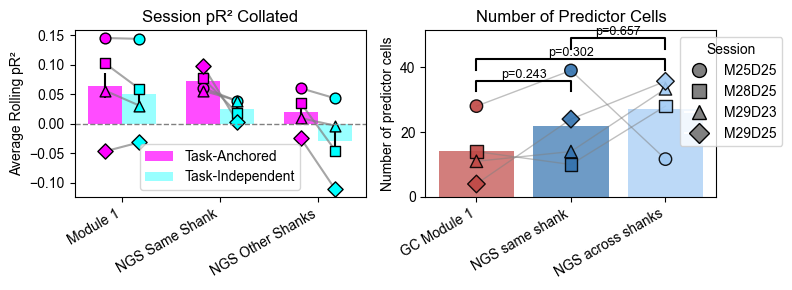

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D

# --- Data prep ---
# Aggregate cell_count per session and group
cell_count_df = results_df.groupby(['session', 'group'])['cell_count'].mean().unstack(fill_value=0)

groups = ['Module 1', 'NGS Same Shank', 'NGS Other Shanks']
group_colors = ['#c04744', "#3171ae", "#a0caf4"]
task_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

sessions = cell_count_df.index.tolist()
bar_width = 0.25
width = 0.35

# Define a list of unique marker styles
marker_styles = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '8', 'p', 'H', 'd', '<', '>', '1', '2', '3', '4', '|', '_']
session_marker_map = {session: marker_styles[i % len(marker_styles)] for i, session in enumerate(sessions)}

fig, axes = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw={'width_ratios': [1, 1]}, sharey=False)

# --- Left subplot: Collated pR² plot ---
ax = axes[0]
for g_idx, g in enumerate(groups):
    df_g = results_df[results_df['group'] == g]
    agg_df = df_g.groupby(['session', 'task_type'])['mean_pr2'].mean().unstack()
    agg_df = agg_df.dropna(subset=['Task-Anchored', 'Task-Independent'])
    for session, row in agg_df.iterrows():
        mouse = results_df[(results_df['session'] == session) & (results_df['group'] == g)]['mouse'].values[0]
        day = results_df[(results_df['session'] == session) & (results_df['group'] == g)]['day'].values[0]
        ti_val = row['Task-Independent']
        ta_val = row['Task-Anchored']
        marker = session_marker_map[session]
        ax.plot([g_idx+width/2, g_idx-width/2], [ti_val, ta_val], color='grey', alpha=0.7, zorder=1)
        ax.scatter(g_idx+width/2, ti_val, color=task_colors['Task-Independent'], edgecolor='k', s=60, zorder=2, marker=marker)
        ax.scatter(g_idx-width/2, ta_val, color=task_colors['Task-Anchored'], edgecolor='k', s=60, zorder=2, marker=marker)
# Plot summary bars
for i, task_type in enumerate(['Task-Anchored', 'Task-Independent']):
    df = results_df[results_df['task_type'] == task_type].groupby('group').agg({'mean_pr2': 'mean', 'sem_pr2': 'mean', 'n_cells': 'sum', 'session': 'nunique'}).reset_index()
    means = [df[df['group'] == g]['mean_pr2'].values[0] if not df[df['group'] == g].empty else np.nan for g in groups]
    sems = [df[df['group'] == g]['sem_pr2'].values[0] if not df[df['group'] == g].empty else np.nan for g in groups]
    for j, g in enumerate(groups):
        ax.bar(j + (i-0.5)*width, means[j], width, yerr=sems[j], label=task_type if j==0 else "", alpha=0.7 if i==0 else 0.4, color=task_colors[task_type], zorder=0)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(np.arange(len(groups)))
ax.set_xticklabels(groups, rotation=30, ha='right')
ax.set_ylabel('Average Rolling pR²')
ax.set_title('Session pR² Collated')
ax.legend()
ax.set_yticks([-0.1, -0.05, 0, 0.05, 0.1, 0.15])

# --- Right subplot: Cell count summary plot ---
ax = axes[1]
avg_cell_count = [cell_count_df[g].mean() if g in cell_count_df.columns else np.nan for g in groups]
x = np.arange(len(groups))
ax.bar(x, avg_cell_count, color=group_colors, alpha=0.7, label='Average cell_count')
for session in cell_count_df.index:
    yvals = [cell_count_df.loc[session, g] if g in cell_count_df.columns else np.nan for g in groups]
    ax.plot(x, yvals, color='grey', alpha=0.5, linewidth=1, zorder=1)
    marker = session_marker_map[session]
    ax.scatter(x, yvals, color=group_colors, edgecolor='k', s=80, zorder=2, alpha=0.9, marker=marker)
ax.set_xticks(x)
ax.set_xticklabels(['GC Module 1', 'NGS same shank', 'NGS across shanks'], rotation=30, ha='right')
ax.set_title('Number of Predictor Cells')
ax.set_ylabel('Number of predictor cells')

# Paired t-tests between groups (annotate on subplot)
pairs = [(0, 1), (0, 2), (1, 2)]
ymax = max(avg_cell_count) + 0.2 * max(avg_cell_count)
for idx, (i, j) in enumerate(pairs):
    mask = (~cell_count_df[groups[i]].isna()) & (~cell_count_df[groups[j]].isna())
    vals_i = cell_count_df[groups[i]][mask]
    vals_j = cell_count_df[groups[j]][mask]
    if len(vals_i) > 1 and len(vals_j) > 1:
        tstat, pval = ttest_rel(vals_i, vals_j)
        x1, x2 = x[i], x[j]
        y, h = ymax + idx*0.2*ymax, 0.1*ymax
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
        ax.text((x1+x2)/2, y+h, f'p={pval:.3g}', ha='center', va='bottom', fontsize=9)

# Add legend for session markers (right subplot)
legend_elements = [Line2D([0], [0], marker=session_marker_map[session], color='w', markerfacecolor='grey', markeredgecolor='k', markersize=10, label=session.replace('_', '').replace('.pkl', '')) for session in cell_count_df.index]
ax.legend(handles=legend_elements, title='Session', loc='upper right', bbox_to_anchor=(1.25, 1))

fig.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/multishank_combined_summary.pdf', dpi=1000)
plt.show()

In [ ]:

predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
]
colors = ['#000000', '#c04744', "#a0caf4", '#3171ae', '#a0caf4', '#a0caf4', '#50104c']
err_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse != 28) or (day != 25):
        continue
    trial_labels, got_from_grid = get_trial_labels(mouse, day)
    print(f'{np.unique(trial_labels)}')
    print(f'mouse {mouse}, day {day}, TA label from grid: {got_from_grid}')
    # Get cell counts for annotation
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )

    figpath_rm = f'/Users/harryclark/Desktop/M{mouse}D{day}'
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'GC', figpath=figpath_rm)
    for shank in range(4):
        plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs[ngs['shank_id'] == shank].cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'NGS Shank {shank}', figpath=figpath_rm)

    cell_counts = [
        0,  # Position (all cells)
        len(g_m_cluster_ids[0]) if len(g_m_cluster_ids) > 0 else 0,  # Module 1
        len(ngs[ngs['shank_id'] == 0]),
        len(ngs[ngs['shank_id'] == 1]),
        len(ngs[ngs['shank_id'] == 2]),
        len(ngs[ngs['shank_id'] == 3]),
        len(all.cluster_id.values),  # All cells
    ]
    groups = list(all_rolling_results_by_group.keys())
    fig, axes = plt.subplots(2, len(groups), figsize=(16/1.1, 6/1.1), sharey=False)
    # Define custom y-limits for each group
    custom_top_ylim = {
        'Module 1': (-0.3, 0.3),
        'Shank 0 NGS': (-0.3, 0.3),
        'Shank 1 NGS': (-0.3, 0.3),
        'Shank 2 NGS': (-0.06, 0.06),
        'Shank 3 NGS': (-0.2, 0.2),
    }
    custom_bottom_ylim = {
        'Module 1': (-0.15, 0.35),
        'Shank 0 NGS': (-0.15, 0.4),
        'Shank 1 NGS': (-0.15, 0.4),
        'Shank 2 NGS': (-0.03, 0.1),
        'Shank 3 NGS': (-0.03, 0.1),
    }

    for col_idx, group_name in enumerate(groups):
        group_df = all_rolling_results_by_group[group_name]
        test_ids = group_df['test_cell_id'].unique()
        ax_top = axes[0, col_idx]
        for i, pred in enumerate(predictors):
            mean_df = group_df.groupby('trial_number')[pred].mean()
            sem_df = group_df.groupby('trial_number')[pred].sem()
            ax_top.plot(mean_df.index, mean_df.values, color=colors[i], label=labels[i])
            ax_top.fill_between(mean_df.index, mean_df.values - sem_df.values, mean_df.values + sem_df.values, color=colors[i], alpha=0.2)
        ax_top.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_top.set_xlabel('Trial Number')
        ax_top.set_title(f'Target cells: {group_name}')
        # Set custom ylim for ax_top if available
        if group_name in custom_top_ylim:
            ax_top.set_ylim(custom_top_ylim[group_name])
        if col_idx == 0:
            ax_top.set_ylabel('Rolling pR²')
        else:
            ax_top.set_ylabel('')
        if trial_labels is not None:
            for label, c in zip([0,1], ['cyan', 'magenta']):
                ax_top.scatter(np.arange(mean_df.index[0], len(trial_labels) + mean_df.index[0])[trial_labels == label], np.ones(len(trial_labels))[trial_labels == label]*ax_top.get_ylim()[1], color=c)

        ax_bottom = axes[1, col_idx]
        means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
        for pred in predictors:
            vals_ti, vals_ta = [], []
            for test_id in test_ids:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
            means_ti.append(np.nanmean(vals_ti))
            means_ta.append(np.nanmean(vals_ta))
            sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
            sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
        x = np.arange(len(predictors))
        width = 0.35
        # Bar plots
        bars1 = ax_bottom.bar(
            x - width/2, means_ti, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Independent'
        )
        bars2 = ax_bottom.bar(
            x + width/2, means_ta, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Anchored'
        )
        # Manually add colored error bars
        for i in range(len(predictors)):
            ax_bottom.errorbar(
                x[i] - width/2, means_ti[i], yerr=sems_ti[i],
                fmt='none', ecolor=err_colors['Task-Independent'], elinewidth=2, capsize=0, zorder=3
            )
            ax_bottom.errorbar(
                x[i] + width/2, means_ta[i], yerr=sems_ta[i],
                fmt='none', ecolor=err_colors['Task-Anchored'], elinewidth=2, capsize=0, zorder=3
            )
        # Annotate cell counts above each bar
        for i in range(len(predictors)):
            ax_bottom.text(x[i], max(means_ti[i]+sems_ti[i], means_ta[i]+sems_ta[i]), f'n={cell_counts[i]}', ha='center', va='bottom', fontsize=10, color=colors[i])
        ax_bottom.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(labels, rotation=30, ha='right')
        # Set custom ylim for ax_bottom if available
        if group_name in custom_bottom_ylim:
            ax_bottom.set_ylim(custom_bottom_ylim[group_name])
        else:
            ax_bottom.set_ylim([-0.1, None])
        if col_idx == 0:
            ax_bottom.set_ylabel('Average Rolling pR²')
        else:
            ax_bottom.set_ylabel('')
    fig.tight_layout()
    plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M28D25_rolling_predictors.pdf')
    plt.show()

In [ ]:
results_path = '/Users/harryclark/Downloads/COHORT12/multishank_xgboost/'
pkl_files = [f for f in os.listdir(results_path) if f.endswith('.pkl')]
loaded_pickles = {}
for fname in pkl_files:
    with open(os.path.join(results_path, fname), 'rb') as f:
        loaded_pickles[fname] = pickle.load(f)
print(f"Loaded {len(loaded_pickles)} pickle files:", list(loaded_pickles.keys()))

predictors = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_shank_0_ngs',
    'rolling_pr2_shank_1_ngs',
    'rolling_pr2_shank_2_ngs',
    'rolling_pr2_shank_3_ngs',
    'rolling_pr2_all_cells',
]
labels = [
    'Position',
    'Module 1',
    'Shank 0 NGS',
    'Shank 1 NGS',
    'Shank 2 NGS',
    'Shank 3 NGS',
    'All Cells',
]
colors = ['#000000', '#c04744', "#a0caf4", '#3171ae', '#a0caf4', '#a0caf4', '#50104c']
err_colors = {'Task-Independent': 'cyan', 'Task-Anchored': 'magenta'}

for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse != 25) or (day != 25):
        continue
    trial_labels, got_from_grid = get_trial_labels(mouse, day)
    print(f'{np.unique(trial_labels)}')
    print(f'mouse {mouse}, day {day}, TA label from grid: {got_from_grid}')
    # Get cell counts for annotation
    gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
        gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
        figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
    )

    figpath_rm = f'/Users/harryclark/Desktop/M{mouse}D{day}'
    plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'GC', figpath=figpath_rm)
    for shank in range(4):
        plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs[ngs['shank_id'] == shank].cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label=f'NGS Shank {shank}', figpath=figpath_rm)

    cell_counts = [
        0,  # Position (all cells)
        len(g_m_cluster_ids[0]) if len(g_m_cluster_ids) > 0 else 0,  # Module 1
        len(ngs[ngs['shank_id'] == 0]),
        len(ngs[ngs['shank_id'] == 1]),
        len(ngs[ngs['shank_id'] == 2]),
        len(ngs[ngs['shank_id'] == 3]),
        len(all.cluster_id.values),  # All cells
    ]
    groups = list(all_rolling_results_by_group.keys())
    fig, axes = plt.subplots(2, len(groups), figsize=(16/1.1, 6/1.1), sharey=False)
    # Define custom y-limits for each group
    custom_top_ylim = {
        'Module 1': (-0.3, 0.3),
        'Shank 0 NGS': (-0.3, 0.3),
        'Shank 1 NGS': (-0.3, 0.3),
        'Shank 2 NGS': (-0.06, 0.06),
        'Shank 3 NGS': (-0.2, 0.2),
    }
    custom_bottom_ylim = {
        'Module 1': (-0.15, 0.35),
        'Shank 0 NGS': (-0.15, 0.4),
        'Shank 1 NGS': (-0.15, 0.4),
        'Shank 2 NGS': (-0.03, 0.1),
        'Shank 3 NGS': (-0.03, 0.1),
    }

    for col_idx, group_name in enumerate(groups):
        group_df = all_rolling_results_by_group[group_name]
        test_ids = group_df['test_cell_id'].unique()
        ax_top = axes[0, col_idx]
        for i, pred in enumerate(predictors):
            mean_df = group_df.groupby('trial_number')[pred].mean()
            sem_df = group_df.groupby('trial_number')[pred].sem()
            ax_top.plot(mean_df.index, mean_df.values, color=colors[i], label=labels[i])
            ax_top.fill_between(mean_df.index, mean_df.values - sem_df.values, mean_df.values + sem_df.values, color=colors[i], alpha=0.2)
        ax_top.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_top.set_xlabel('Trial Number')
        ax_top.set_title(f'Target cells: {group_name}')
        # Set custom ylim for ax_top if available
        if group_name in custom_top_ylim:
            ax_top.set_ylim(custom_top_ylim[group_name])
        if col_idx == 0:
            ax_top.set_ylabel('Rolling pR²')
        else:
            ax_top.set_ylabel('')
        if trial_labels is not None:
            for label, c in zip([0,1], ['cyan', 'magenta']):
                ax_top.scatter(np.arange(mean_df.index[0], len(trial_labels) + mean_df.index[0])[trial_labels == label], np.ones(len(trial_labels))[trial_labels == label]*ax_top.get_ylim()[1], color=c)

        ax_bottom = axes[1, col_idx]
        means_ti, means_ta, sems_ti, sems_ta = [], [], [], []
        for pred in predictors:
            vals_ti, vals_ta = [], []
            for test_id in test_ids:
                df_cell = group_df[group_df['test_cell_id'] == test_id].reset_index(drop=True)
                if trial_labels is not None:
                    mask_ti = (trial_labels[:len(df_cell)] == 0)
                    mask_ta = (trial_labels[:len(df_cell)] == 1)
                else:
                    mask_ti = np.zeros(len(df_cell), dtype=bool)
                    mask_ta = np.zeros(len(df_cell), dtype=bool)
                vals_ti.append(np.nanmean(df_cell[pred][mask_ti]))
                vals_ta.append(np.nanmean(df_cell[pred][mask_ta]))
            means_ti.append(np.nanmean(vals_ti))
            means_ta.append(np.nanmean(vals_ta))
            sems_ti.append(np.nanstd(vals_ti) / np.sqrt(len(vals_ti)))
            sems_ta.append(np.nanstd(vals_ta) / np.sqrt(len(vals_ta)))
        x = np.arange(len(predictors))
        width = 0.35
        # Bar plots
        bars1 = ax_bottom.bar(
            x - width/2, means_ti, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Independent'
        )
        bars2 = ax_bottom.bar(
            x + width/2, means_ta, width, color=colors, edgecolor='black', alpha=0.7, label='Task-Anchored'
        )
        # Manually add colored error bars
        for i in range(len(predictors)):
            ax_bottom.errorbar(
                x[i] - width/2, means_ti[i], yerr=sems_ti[i],
                fmt='none', ecolor=err_colors['Task-Independent'], elinewidth=2, capsize=0, zorder=3
            )
            ax_bottom.errorbar(
                x[i] + width/2, means_ta[i], yerr=sems_ta[i],
                fmt='none', ecolor=err_colors['Task-Anchored'], elinewidth=2, capsize=0, zorder=3
            )
        # Annotate cell counts above each bar
        for i in range(len(predictors)):
            ax_bottom.text(x[i], max(means_ti[i]+sems_ti[i], means_ta[i]+sems_ta[i]), f'n={cell_counts[i]}', ha='center', va='bottom', fontsize=10, color=colors[i])
        ax_bottom.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(labels, rotation=30, ha='right')
        # Set custom ylim for ax_bottom if available
        if group_name in custom_bottom_ylim:
            ax_bottom.set_ylim(custom_bottom_ylim[group_name])
        else:
            ax_bottom.set_ylim([-0.1, None])
        if col_idx == 0:
            ax_bottom.set_ylabel('Average Rolling pR²')
        else:
            ax_bottom.set_ylabel('')
    fig.tight_layout()
    plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/M28D25_rolling_predictors.pdf')
    plt.show()

25 25
optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
optimal travel lag is 5.755755755755757 cm
there are 110 non_grid and non_spatial_cells
there are 36 grid_cells
there are 74 non grid spatial cells
there are 36 non spatial cells
there are 0 speed cells
there are 146 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl1' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl2/3']
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.931271762229468
Found 3 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 1  5 30]


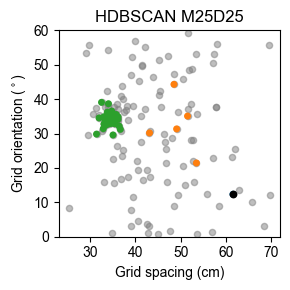

for module 0, there are 5 cells with average spacing 49.153961296236965
for module 1, there are 30 cells with average spacing 34.29724377249578
Identified 1 candidate modules


In [12]:
mouse = 25
day = 25

gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95)

ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(
    gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3,
    figpath=None, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False
)
tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False) 

tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in g_m_cluster_ids[0] if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3]
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring
labels = np.isin(max_peaks, [28, 44, 60, 76]).astype(int) # these are the peaks that correspond to the task anchoring


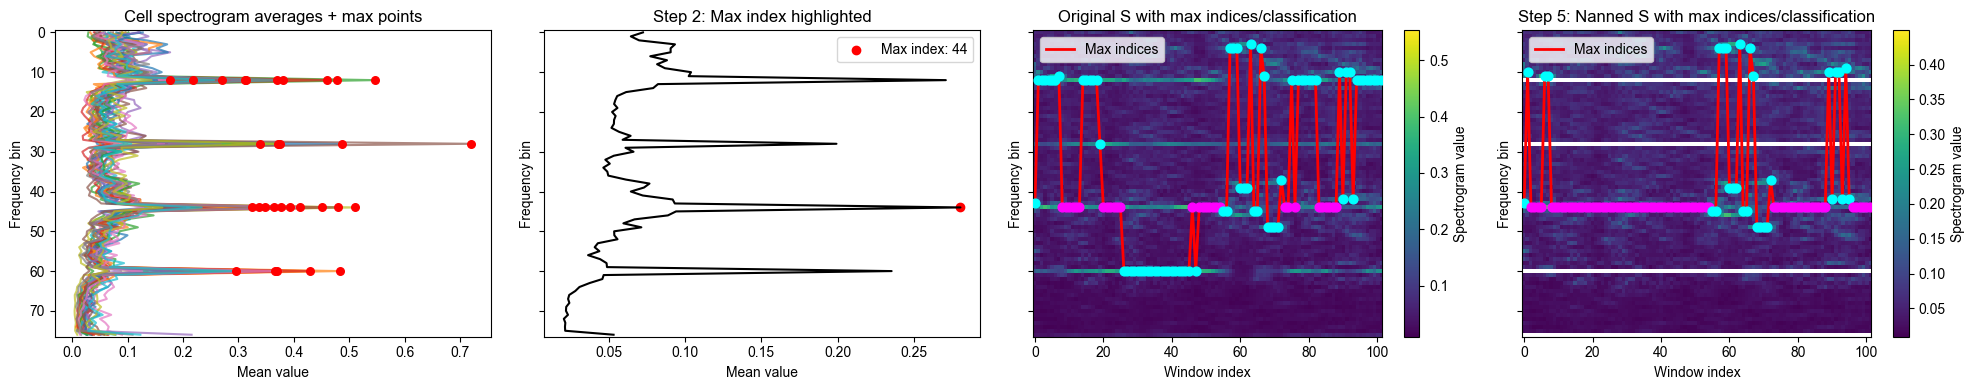

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def classify_and_plot_max_indices_subplot(spectrograms, special_indices=[12, 28, 44, 60, 76]):
    """
    Plots:
    - First: For each cell's spectrogram, plot the average (one line per cell) and scatter the maximal point for each cell
    - Second: Average across all cells (step 2: max index highlighted)
    - Third: Original S spectrogram with max indices and classification overlayed
    - Fourth: Spectrogram with nanned special indices, max indices and classification overlayed (step 5)
    Returns:
    - classification_nanned: np.ndarray of 0/1 labels for each time bin (step 5 classification)
    """
    # spectrograms: shape (n_cells, n_freq_bins, n_time_bins)
    n_cells = spectrograms.shape[0]
    cell_averages = [spectrograms[i].mean(axis=1) for i in range(n_cells)]
    max_indices_cells = [np.argmax(avg) for avg in cell_averages]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    # First subplot: all cell averages and scatter maximal points
    for i, avg in enumerate(cell_averages):
        axes[0].plot(avg, np.arange(len(avg)), alpha=0.7)
        axes[0].scatter(avg[max_indices_cells[i]], max_indices_cells[i], color='red', s=30, zorder=3)
    axes[0].set_title("Cell spectrogram averages + max points")
    axes[0].set_xlabel("Mean value")
    axes[0].set_ylabel("Frequency bin")

    S = spectrograms.mean(0)
    S_avg = S.mean(axis=1)
    max_idx = np.argmax(S_avg)
    S_nanned = S.copy()
    if max_idx in special_indices:
        for idx in special_indices:
            if idx != max_idx:
                S_nanned[idx, :] = np.nan
    def safe_nanargmax(row):
        if np.all(np.isnan(row)):
            return np.nan
        else:
            return np.nanargmax(row)
    max_indices_nanned = np.apply_along_axis(safe_nanargmax, 0, S_nanned)
    classification_nanned = (max_indices_nanned == max_idx).astype(int)
    def safe_nanargmax_orig(row):
        if np.all(np.isnan(row)):
            return np.nan
        else:
            return np.nanargmax(row)
    max_indices_orig = np.apply_along_axis(safe_nanargmax_orig, 0, S)
    classification_orig = (max_indices_orig == max_idx).astype(int)

    # Second subplot: Step 2
    axes[1].plot(S_avg, np.arange(len(S_avg)), color='black')
    axes[1].scatter(S_avg[max_idx], max_idx, color='red', label=f"Max index: {max_idx}")
    axes[1].set_title("Step 2: Max index highlighted")
    axes[1].set_xlabel("Mean value")
    axes[1].set_ylabel("Frequency bin")
    axes[1].legend()

    # Third subplot: Original S spectrogram
    im0 = axes[2].imshow(S, aspect='auto', interpolation='none')
    axes[2].plot(np.arange(len(max_indices_orig)), max_indices_orig, color='red', linewidth=2, label='Max indices')
    for t, cls in enumerate(classification_orig):
        if not np.isnan(max_indices_orig[t]):
            color = 'magenta' if cls == 1 else 'cyan'
            axes[2].scatter(t, max_indices_orig[t], color=color, s=40, edgecolor=color, zorder=3)
    axes[2].set_title("Original S with max indices/classification")
    axes[2].set_xlabel("Window index")
    axes[2].set_ylabel("Frequency bin")
    axes[2].legend()
    fig.colorbar(im0, ax=axes[2], label='Spectrogram value')

    # Fourth subplot: Step 5
    im = axes[3].imshow(S_nanned, aspect='auto', interpolation='none')
    axes[3].plot(np.arange(len(max_indices_nanned)), max_indices_nanned, color='red', linewidth=2, label='Max indices')
    for t, cls in enumerate(classification_nanned):
        if not np.isnan(max_indices_nanned[t]):
            color = 'magenta' if cls == 1 else 'cyan'
            axes[3].scatter(t, max_indices_nanned[t], color=color, s=40, edgecolor=color, zorder=3)
    axes[3].set_title("Step 5: Nanned S with max indices/classification")
    axes[3].set_xlabel("Window index")
    axes[3].set_ylabel("Frequency bin")
    axes[3].legend()
    fig.colorbar(im, ax=axes[3], label='Spectrogram value')

    fig.tight_layout()
    plt.show()

    return classification_nanned

# Example usage:
labels = classify_and_plot_max_indices_subplot(spectrograms)

In [ ]:
import pandas as pd

results = []

sessions_of_interest = [(25, 25), (28, 25), (29, 23), (29, 25)]
for fname, all_rolling_results_by_group in loaded_pickles.items():
    mouse, day = extract_mouse_day(fname)
    if (mouse, day) not in sessions_of_interest:
        continue

    # Get trial labels (task anchoring)
    trial_labels, _ = get_trial_labels(mouse, day)
    # Get cell metadata
    gcs, ngs, ns, sc, ngs_ns, all_cells = cell_classification_of1(mouse, day, percentile_threshold=95)
    ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')
    gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
    gcs['cell_type'] = 'GC'
    ngs['cell_type'] = 'NGS'
    all_cells = pd.concat([gcs, ngs], ignore_index=True)
    
    dominant_shank = get_module_1_dominant_shank(g_m_cluster_ids, locations, mouse, day)
    
    # For each cell
    for _, cell in all_cells.iterrows():
        cluster_id = cell['cluster_id']
        shank_id = cell['shank_id']
        shank_type = 'same_shank' if shank_id == dominant_shank else 'across_shank'
        cell_type = cell['cell_type']

        tc = tcs[cluster_id]
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin] # only want bins with ephys data in it
        tcz = zscore(tc)
        bin_config = get_bin_config('VR')
        trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
 
        for firing_mode, label in zip(['TA', 'TI'], [1, 0]):
            trials = beh['trials'][:len(trial_labels)]
            trials = trials[trial_labels == label]
            #print(f'Computing spatial info for {mouse} {day} {cell_type} {firing_mode} {cluster_id}, with {len(trials)} trials')
            x, y = get_avg_profile(tc, bs, tl, mask=trial_labels==label)

            spatial_info = nap.compute_1d_mutual_info(y.reshape(-1, 1), 
                                                        beh['P'], 
                                                        ep=beh['moving'].intersect(trials), 
                                                        minmax=bin_config['P']['bounds'])['SI'].iloc[0]

            results.append({
                'cluster_id': cluster_id,
                'shank_id': shank_id,
                'cell_type': cell_type,
                'mouse_id': mouse,
                'day_id': day,
                'firing_mode': firing_mode,
                'spatial_info': spatial_info,
            })

df = pd.DataFrame(results)

In [52]:
M2D6 = pd.read_csv('/Users/harryclark/Desktop/M02_D06_MMNAV2_blender.csv')

In [87]:
def generate_position_data_from_blender_file(file_path, image_length_cm=40):
    blender_data = pd.read_csv(file_path, skiprows=4, sep=";",
                               names=["Time", "Position-X", "Speed", "Speed/gain_mod", "Reward_received",
                                      "Reward_failed", "Lick_detected", "Tone_played", "Position-Y",
                                      "Tot trial", "gain_mod", "rz_start", "rz_end", "sync_pulse"])
    blender_data = blender_data.dropna()
    position_data = pd.DataFrame()
    position_data["x_position_cm"] = blender_data["Position-X"]*10 # assumes 10 cm per virtual unit
    position_data["trial_number"] = blender_data["Tot trial"]-2
    position_data['sequence_number'] = position_data["trial_number"]//6
    position_data["distance_travelled_cm"] = ((position_data["sequence_number"])*image_length_cm*6)+position_data['x_position_cm']
    position_data['recomputed_x_position_cm'] = position_data['distance_travelled_cm'] % (image_length_cm*6)
    position_data["time_seconds"] = blender_data["Time"]
    position_data["speed_as_read_by_blender"] = blender_data["Speed"]
    position_data["Reward_received_as_read_by_blender"] = blender_data["Reward_received"]
    position_data["Tone_played_as_read_by_blender"] = blender_data["Tone_played"]
    position_data["sync_pulse"] = blender_data["sync_pulse"]
    position_data["dwell_time_ms"] = np.append(0, np.diff(position_data["time_seconds"]))
    return position_data

In [85]:
position_data = generate_position_data_from_blender_file('/Users/harryclark/Desktop/M02_D06_MMNAV2_blender.csv')
position_data

,x_position_cm,trial_number,sequence_number,distance_travelled_cm,recomputed_x_position_cm,time_seconds,speed_as_read_by_blender,Reward_received_as_read_by_blender,Tone_played_as_read_by_blender,sync_pulse,dwell_time_ms
0,-0.037699,0,0,-80.037699,39.962301,0.058569,17330.121484,0,0,0,0.000000
1,-0.037699,0,0,-80.037699,39.962301,0.058893,18115.259074,0,0,0,0.000324
2,-0.037699,0,0,-80.037699,39.962301,0.059142,-89.759758,0,0,0,0.000249
3,-0.037699,0,0,-80.037699,39.962301,0.059381,0.000000,0,0,0,0.000239
4,-0.037699,0,0,-80.037699,39.962301,0.059623,0.000000,0,0,0,0.000242
...,...,...,...,...,...,...,...,...,...,...,...
146024,12.629198,325,54,12932.629198,12.629198,2433.752217,10.041044,0,0,0,0.016087
146025,12.943357,325,54,12932.943357,12.943357,2433.769064,11.252536,0,0,0,0.016847
146026,13.169552,325,54,12933.169552,13.169552,2433.786107,14.272279,0,0,0,0.017042
146027,13.383180,325,54,12933.383180,13.383180,2433.802329,16.494315,0,0,0,0.016222


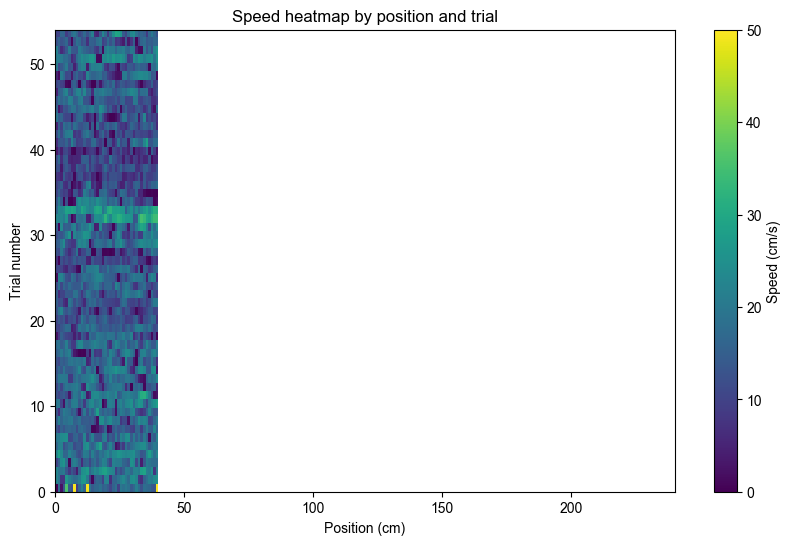

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Example pos_data and speed_in_time, trial_number_in_time (replace with your actual data)
# pos_data: array of positions (cm), speed_in_time: array of speeds, trial_number_in_time: array of trial numbers
pos_data = np.array(position_data['recomputed_x_position_cm'])
speed_data = np.array(position_data['speed_as_read_by_blender'])
trial_data = np.array(position_data['sequence_number'])

# Bin positions from 0 to 40cm
n_bins = 40*6
pos_bins = np.linspace(0, 40*6, n_bins+1)
bin_indices = np.digitize(pos_data, pos_bins) - 1  # bin indices for each position

# Get unique trials
unique_trials = np.unique(trial_data)
heatmap = np.full((len(unique_trials), n_bins), np.nan)

# For each trial, compute mean speed in each position bin
for i, trial in enumerate(unique_trials):
    mask_trial = (trial_data == trial)
    for b in range(n_bins):
        mask_bin = (bin_indices == b) & mask_trial
        if np.any(mask_bin):
            heatmap[i, b] = np.nanmean(speed_data[mask_bin])

plt.figure(figsize=(10, 6))
plt.imshow(heatmap, aspect='auto', interpolation='none', origin='lower', extent=[0, 40*6, unique_trials[0], unique_trials[-1]], vmin=0, vmax=50)
plt.colorbar(label='Speed (cm/s)')
plt.xlabel('Position (cm)')
plt.ylabel('Trial number')
plt.title('Speed heatmap by position and trial')
plt.show()